<a href="https://colab.research.google.com/github/FaizFP/Dicoding--Image/blob/main/Template_Submission_Akhir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Faiz Firdaus Priyanto
- **Email:** m331d5y0573@student.devacademy.id
- **ID Dicoding:** m331d5y0573

## Import Semua Packages/Library yang Digunakan

In [1]:
import zipfile
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import shutil
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
!pip install tensorflowjs
from PIL import Image


## Data Preparation

In [2]:
# Path file zip
zip_path = "/content/sample_data/shoessandalboot.zip"

# Folder tujuan ekstraksi
extract_dir = "/content/sample_data/shoessandalboot"

# Ekstrak file zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Ekstraksi selesai di:", extract_dir)
print("Isi folder:", os.listdir(extract_dir))

✅ Ekstraksi selesai di: /content/sample_data/shoessandalboot
Isi folder: ['Shoe vs Sandal vs Boot Dataset']


### Data Loading

In [3]:

data_dir = "/content/sample_data/shoessandalboot/Shoe vs Sandal vs Boot Dataset"

# List semua folder di dalam data_dir
folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]

print("Jumlah folder (kelas) :", len(folders))
print("Nama folder (kelas)  :", folders)

Jumlah folder (kelas) : 3
Nama folder (kelas)  : ['Sandal', 'Shoe', 'Boot']


### Data Preprocessing

Jumlah kelas: 3
Nama kelas : ['Sandal', 'Shoe', 'Boot']

Kelas 'Sandal' memiliki 5000 gambar
Resolusi contoh gambar 'Sandal (368).jpg' : (136, 102)


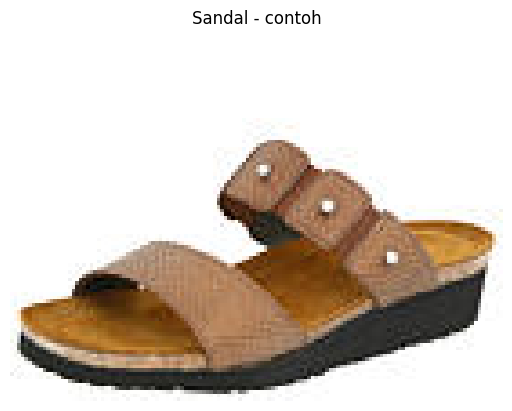


Kelas 'Shoe' memiliki 5000 gambar
Resolusi contoh gambar 'Shoe (4830).jpg' : (136, 102)


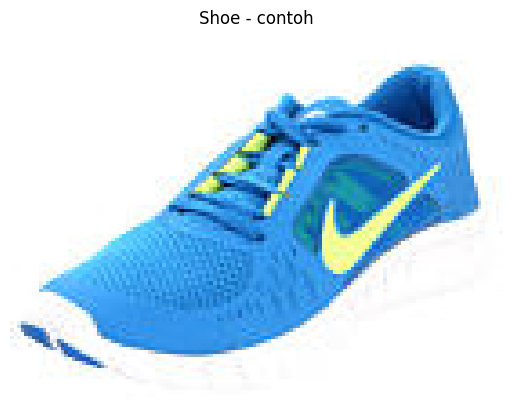


Kelas 'Boot' memiliki 5000 gambar
Resolusi contoh gambar 'boot (2020).jpg' : (136, 102)


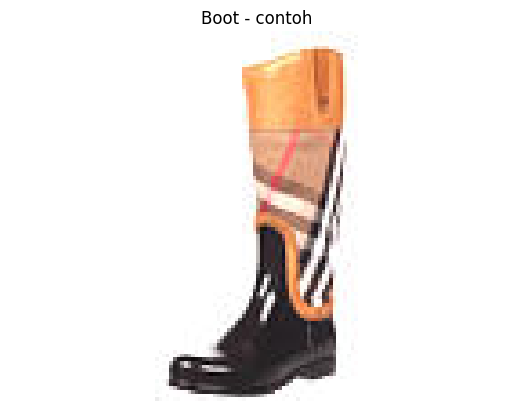

In [4]:
# --- List folder (kelas) ---
class_folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
print("Jumlah kelas:", len(class_folders))
print("Nama kelas :", class_folders)

# --- Loop tiap kelas ---
for cls in class_folders:
    cls_path = os.path.join(data_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"\nKelas '{cls}' memiliki {len(images)} gambar")

    if images:
        # Ambil gambar pertama untuk cek resolusi
        img_path = os.path.join(cls_path, images[0])
        img = Image.open(img_path)
        print(f"Resolusi contoh gambar '{images[0]}' : {img.size}")  # (width, height)

        # Tampilkan gambar
        plt.imshow(img)
        plt.title(f"{cls} - contoh")
        plt.axis('off')
        plt.show()

#### Split Dataset

In [5]:
# Folder baru untuk split
base_split_dir = "/content/sample_data/shoessandalboot_split"
train_dir = os.path.join(base_split_dir, "train")
val_dir   = os.path.join(base_split_dir, "val")
test_dir  = os.path.join(base_split_dir, "test")

# Buat folder split
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# Rasio split
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

# Loop setiap kelas
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # Ambil semua file gambar
    images = os.listdir(class_path)
    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)

    # Split
    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train+n_val]
    test_imgs  = images[n_train+n_val:]

    # Buat folder kelas di train/val/test
    for split, split_imgs in zip([train_dir, val_dir, test_dir],
                                 [train_imgs, val_imgs, test_imgs]):
        class_split_dir = os.path.join(split, class_name)
        os.makedirs(class_split_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(class_split_dir, img))

print("✅ Dataset berhasil di-split!")
print("Contoh folder train:", os.listdir(train_dir))

✅ Dataset berhasil di-split!
Contoh folder train: ['Sandal', 'Shoe', 'Boot']


**DATA AUGMENTASI UNTUK TRAINING**

In [6]:
train_dir = "/content/sample_data/shoessandalboot_split/train"
# 1️⃣ Data augmentation untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalisasi
    rotation_range=20,       # rotasi acak
    width_shift_range=0.2,   # geser horizontal
    height_shift_range=0.2,  # geser vertikal
    shear_range=0.2,         # shear
    zoom_range=0.2,          # zoom
    horizontal_flip=True
)

# 2️⃣ Data validasi dan testing hanya normalisasi
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Generator training
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Generator validasi
val_data = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generator testing
test_data = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("✅ Data loading & preprocessing selesai")
print("Kelas yang terdeteksi:", train_data.class_indices)

Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
✅ Data loading & preprocessing selesai
Kelas yang terdeteksi: {'Boot': 0, 'Sandal': 1, 'Shoe': 2}


## Modelling

In [7]:
# Ukuran input
IMG_HEIGHT = 150
IMG_WIDTH = 150
CHANNELS = 3
NUM_CLASSES = 3  # boot, sandal, shoe

# 1️⃣ Load pretrained MobileNetV2 sebagai feature extractor
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    include_top=False,  # tanpa fully connected layer
    weights='imagenet'
)
base_model.trainable = False  # freeze weights

# 2️⃣ Bangun model Sequential
model = Sequential([
    base_model,  # pretrained CNN
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')  # output 3 kelas
])

# 3️⃣ Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4️⃣ Ringkasan model
model.summary()

/tmp/ipython-input-2528086324.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,653,859 (10.12 MB)

 Trainable params: 395,875 (1.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

CALLBACKS

In [8]:
# 1️⃣ Simpan model terbaik
checkpoint_cb = ModelCheckpoint(
    "best_model.h5",
    save_best_only=True,
    monitor="val_loss",
    verbose=1
)

# 2️⃣ Hentikan training jika val_loss tidak membaik
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,  # tunggu 5 epoch
    restore_best_weights=True,
    verbose=1
)

# 3️⃣ Turunkan learning rate jika stuck
reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,      # turunkan LR menjadi setengah
    patience=3,      # tunggu 3 epoch
    verbose=1
)

# 4️⃣ Training model dengan callbacks
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7049 - loss: 0.6629
Epoch 1: val_loss improved from inf to 0.16852, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 115s 276ms/step - accuracy: 0.7052 - loss: 0.6623 - val_accuracy: 0.9400 - val_loss: 0.1685 - learning_rate: 1.0000e-04
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9100 - loss: 0.2510
Epoch 2: val_loss improved from 0.16852 to 0.14153, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.9100 - loss: 0.2509 - val_accuracy: 0.9538 - val_loss: 0.1415 - learning_rate: 1.0000e-04
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9188 - loss: 0.2211
Epoch 3: val_loss improved from 0.14153 to 0.11965, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 63s 191ms/step - accuracy: 0.9188 - loss: 0.2210 - val_accuracy: 0.9573 - val_loss: 0.1197 - learning_rate: 1.0000e-04
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9340 - loss: 0.1943
Epoch 4: val_loss improved from 0.11965 to 0.10827, saving model to best_model.h5


...

329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.9564 - loss: 0.1233 - val_accuracy: 0.9680 - val_loss: 0.0929 - learning_rate: 5.0000e-05
Epoch 10/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9596 - loss: 0.1236
Epoch 10: val_loss did not improve from 0.09292
329/329 ━━━━━━━━━━━━━━━━━━━━ 63s 190ms/step - accuracy: 0.9596 - loss: 0.1236 - val_accuracy: 0.9636 - val_loss: 0.1060 - learning_rate: 5.0000e-05
Epoch 11/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9567 - loss: 0.1226
Epoch 11: val_loss improved from 0.09292 to 0.09218, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 63s 192ms/step - accuracy: 0.9567 - loss: 0.1226 - val_accuracy: 0.9689 - val_loss: 0.0922 - learning_rate: 5.0000e-05
Epoch 12/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9604 - loss: 0.1098
Epoch 12: val_loss did not improve from 0.09218
329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 187ms/step - accuracy: 0.9604 - loss: 0.1098 - val_accuracy: 0.9684 - val_loss: 0.0935 - learning_rate: 5.0000e-05
Epoch 13/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9604 - loss: 0.1112
Epoch 13: val_loss improved from 0.09218 to 0.08722, saving model to best_model.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 188ms/step - accuracy: 0.9604 - loss: 0.1112 - val_accuracy: 0.9702 - val_loss: 0.0872 - learning_rate: 5.0000e-05
Epoch 14/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9575 - loss: 0.1162
Epoch 14: val_loss did not improve from 0.08722
329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 187ms/step - accuracy: 0.9575 - loss: 0.1162 - val_accuracy: 0.9693 - val_loss: 0.0879 - learning_rate: 5.0000e-05
Epoch 15/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9579 - loss: 0.1177
Epoch 15: val_loss did not improve from 0.08722
329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 186ms/step - accuracy: 0.9579 - loss: 0.1177 - val_accuracy: 0.9680 - val_loss: 0.0910 - learning_rate: 5.0000e-05
Epoch 16/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9627 - loss: 0.0992
Epoch 16: val_loss did not improve from 0.08722

Epoch 16: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
329/329 ━━━━━━━━━━━━━━━━━━━━ 61s 187ms/step - accuracy: 0.9627 - lo

329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 187ms/step - accuracy: 0.9696 - loss: 0.0922 - val_accuracy: 0.9711 - val_loss: 0.0816 - learning_rate: 2.5000e-05
Epoch 18/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9650 - loss: 0.0950
Epoch 18: val_loss did not improve from 0.08164
329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.9651 - loss: 0.0950 - val_accuracy: 0.9720 - val_loss: 0.0833 - learning_rate: 2.5000e-05
Epoch 19/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9663 - loss: 0.0988
Epoch 19: val_loss did not improve from 0.08164
329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.9663 - loss: 0.0988 - val_accuracy: 0.9707 - val_loss: 0.0846 - learning_rate: 2.5000e-05
Epoch 20/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9677 - loss: 0.0854
Epoch 20: val_loss did not improve from 0.08164

Epoch 20: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
329/329 ━━━━━━━━━━━━━━━━━━━━ 63s 190ms/step - accuracy: 0.9677 - lo

329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 188ms/step - accuracy: 0.9701 - loss: 0.0833 - val_accuracy: 0.9707 - val_loss: 0.0787 - learning_rate: 1.2500e-05
Epoch 23/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9716 - loss: 0.0763
Epoch 23: val_loss did not improve from 0.07872
329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 188ms/step - accuracy: 0.9716 - loss: 0.0763 - val_accuracy: 0.9747 - val_loss: 0.0870 - learning_rate: 1.2500e-05
Epoch 24/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9689 - loss: 0.0907
Epoch 24: val_loss did not improve from 0.07872
329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 187ms/step - accuracy: 0.9689 - loss: 0.0907 - val_accuracy: 0.9716 - val_loss: 0.0856 - learning_rate: 1.2500e-05
Epoch 25/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9686 - loss: 0.0897
Epoch 25: val_loss did not improve from 0.07872

Epoch 25: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
329/329 ━━━━━━━━━━━━━━━━━━━━ 62s 188ms/step - accuracy: 0.9686 - los

In [9]:
from sklearn.metrics import classification_report
import numpy as np

In [10]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step
Pastikan urutan ini sesuai dengan list Anda:
{'Boot': 0, 'Sandal': 1, 'Shoe': 2}


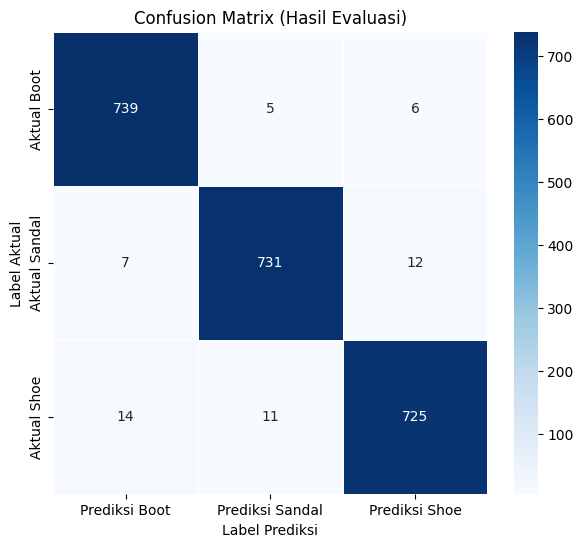


Laporan Klasifikasi (Classification Report):
              precision    recall  f1-score   support

        Boot     0.9724    0.9853    0.9788       750
      Sandal     0.9786    0.9747    0.9766       750
        Shoe     0.9758    0.9667    0.9712       750

    accuracy                         0.9756      2250
   macro avg     0.9756    0.9756    0.9755      2250
weighted avg     0.9756    0.9756    0.9755      2250



In [11]:
# Reset generator validasi
test_data.reset()

# Lakukan prediksi pada data validasi
probabilitas_prediksi = model.predict(test_data, verbose=1)

# Ambil label kelas dengan probabilitas tertinggi
label_prediksi_final = np.argmax(probabilitas_prediksi, axis=1)


# --- 2. Persiapan Label untuk Visualisasi ---
# Cek urutan kelas dari generator (PENTING)
print("Pastikan urutan ini sesuai dengan list Anda:")
print(test_data.class_indices)
# Contoh output: {'Boot': 0, 'Sandal': 1, 'Shoe': 2}

# Buat list nama kelas SESUAI URUTAN di atas
daftar_nama_kelas = ['Boot', 'Sandal', 'Shoe']  # <-- Sesuaikan urutan ini

# Buat list label untuk baris (Y-axis) heatmap
label_baris_aktual = [f"Aktual {nama}" for nama in daftar_nama_kelas]

# Buat list label untuk kolom (X-axis) heatmap
label_kolom_prediksi = [f"Prediksi {nama}" for nama in daftar_nama_kelas]

# --- 3. Buat Confusion Matrix ---
# Hitung confusion matrix
matriks_konfusi = confusion_matrix(test_data.classes, label_prediksi_final)

# Konversi matrix menjadi DataFrame Pandas untuk plotting
df_matriks_konfusi = pd.DataFrame(matriks_konfusi,
                                  index=label_baris_aktual,
                                  columns=label_kolom_prediksi)

# Plot Heatmap Confusion Matrix
plt.figure(figsize=(7, 6)) # Sedikit saya besarkan agar label pas
sns.heatmap(df_matriks_konfusi, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix (Hasil Evaluasi)")
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.show()


# --- 4. Cetak Classification Report ---

print("\nLaporan Klasifikasi (Classification Report):")
print(classification_report(test_data.classes, label_prediksi_final,
                            target_names=daftar_nama_kelas, digits=4))



```

```

## Evaluasi dan Visualisasi

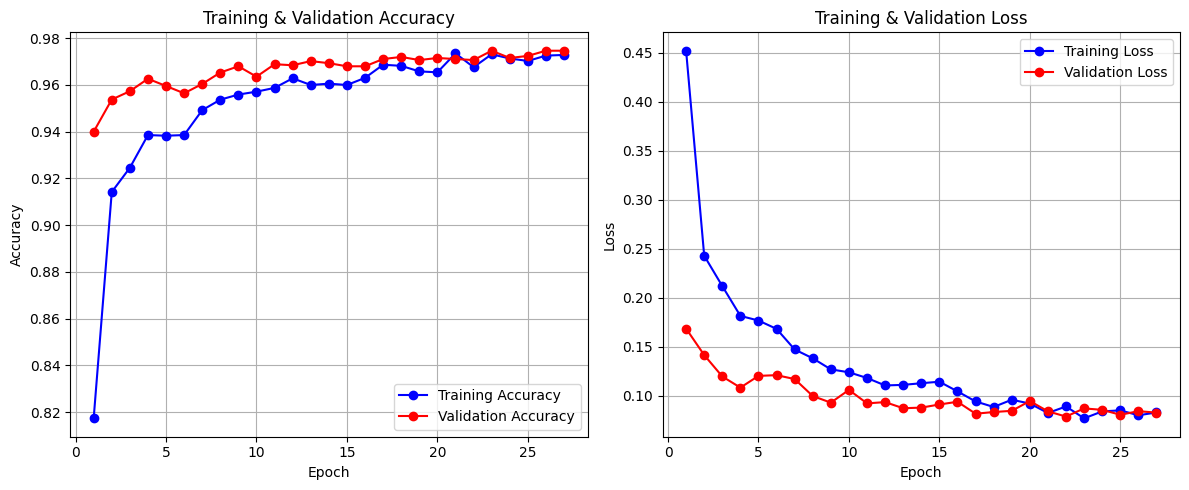

In [12]:
# --- Ambil history training ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# --- Plot Akurasi ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Konversi Model

In [13]:
# --- Folder untuk SavedModel ---
saved_model_path = 'savedModels'
os.makedirs(saved_model_path, exist_ok=True)

# --- Load model Keras ---
model = tf.keras.models.load_model("best_model.h5")

# --- Export ke SavedModel (Keras 3) ---
model.export(saved_model_path)  # buat saved_model.pb + variables/

print(f"✅ Model berhasil diexport ke folder '{saved_model_path}' sebagai SavedModel")

Saved artifact at 'savedModels'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134886878142992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878145488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878145296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878142608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878146064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878143760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878145680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878145872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878143184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878147216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886878146448: T

## MODEL TF LITE

In [14]:
# --- Buat folder tflite jika belum ada ---
os.makedirs('tflite', exist_ok=True)

# --- Load model Keras ---
model = tf.keras.models.load_model("best_model.h5")

# --- Konversi ke TensorFlow Lite ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# --- Simpan model .tflite ---
tflite_path = os.path.join('tflite', 'model_sepatu.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# --- Buat label.txt ---
labels = ['boot', 'sandal', 'shoe']
label_path = os.path.join('tflite', 'label.txt')
with open(label_path, 'w') as f:
    for label in labels:
        f.write(label + '\n')


Saved artifact at '/tmp/tmp9lryjeci'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134886773259152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886773258384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886773257808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886773258768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886773258192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886773257424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134889320000464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134889319999312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134889320001040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886773259344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1348867732570

## TENSOFRLOW JS

In [15]:
import tensorflowjs as tfjs

# Load model Keras (.h5)
model = tf.keras.models.load_model('best_model.h5')

# Convert dan simpan ke folder TF.js
tfjs.converters.save_keras_model(model, 'model_js')


failed to lookup keras version from the file,
    this is likely a weight only file


### Inference (Optional)

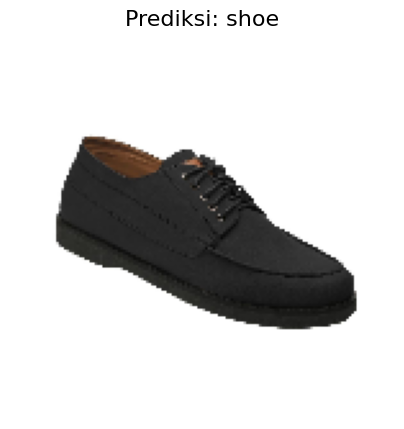

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

# --- Path SavedModel ---
saved_model_path = 'savedModels'

# --- Buat TFSMLayer ---
model = tf.keras.Sequential([
    tf.keras.layers.TFSMLayer(saved_model_path, call_endpoint='serving_default')
])

# --- Label ---
labels = ['boot', 'sandal', 'shoe']

# --- Fungsi load & preprocess JPG ---
def load_and_preprocess(img_path, target_size=(150, 150)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, np.array(img)  # convert ke NumPy array untuk plt.imshow

# --- Path gambar ---
img_path = '/content/sample_data/10.jpg'
img_input, img_orig = load_and_preprocess(img_path)

# --- Prediksi ---
pred_dict = model(img_input)
pred = pred_dict['output_0'].numpy()
pred_label = labels[np.argmax(pred)]

# --- Visualisasi ---
plt.figure(figsize=(5,5))
plt.imshow(img_orig.astype('uint8'))
plt.axis('off')
plt.title(f"Prediksi: {pred_label}", fontsize=16)
plt.show()

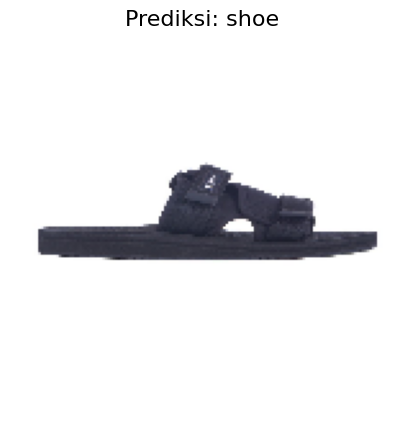

In [18]:
# --- Path gambar ---
img_path = '/content/sample_data/S01112318HT_2.jpeg'
img_input, img_orig = load_and_preprocess(img_path)

# --- Prediksi ---
pred_dict = model(img_input)
pred = pred_dict['output_0'].numpy()
pred_label = labels[np.argmax(pred)]

# --- Visualisasi ---
plt.figure(figsize=(5,5))
plt.imshow(img_orig.astype('uint8'))
plt.axis('off')
plt.title(f"Prediksi: {pred_label}", fontsize=16)
plt.show()

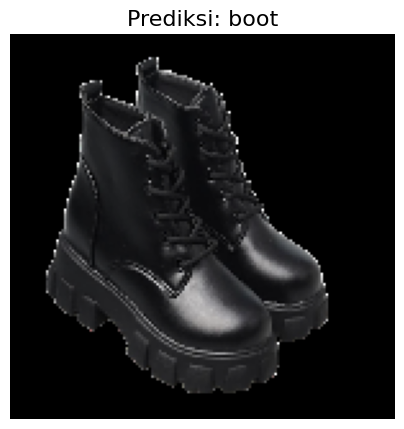

In [19]:

# --- Path gambar ---
img_path = '/content/sample_data/a89c6d8e8f03b77f60e3f1a45391f0e7.png'
img_input, img_orig = load_and_preprocess(img_path)

# --- Prediksi ---
pred_dict = model(img_input)
pred = pred_dict['output_0'].numpy()
pred_label = labels[np.argmax(pred)]

# --- Visualisasi ---
plt.figure(figsize=(5,5))
plt.imshow(img_orig.astype('uint8'))
plt.axis('off')
plt.title(f"Prediksi: {pred_label}", fontsize=16)
plt.show()

In [20]:
pip freeze > requirements.txt
